# Air Quality Index (AQI) Prediction Using Machine Learning

**Problem Statement**

Air pollution is one of the most serious environmental and public health challenges in India. Harmful pollutants such as PM2.5, PM10, NO, NO₂, NOx, NH₃, CO, SO₂, O₃, Benzene, Toluene, and Xylene significantly affect the Air Quality Index (AQI). Monitoring AQI is essential for understanding air quality and taking preventive measures to protect public health.

The objective of this project is to develop a Machine Learning Regression Model that predicts the Air Quality Index (AQI) based on various air pollutant concentrations and the city. The project includes data preprocessing, feature engineering, model training, model evaluation, hyperparameter tuning, and deployment using Streamlit.

**Project Objective**

- Develop a Machine Learning model to predict Air Quality Index (AQI).
- Handle missing values ,encode the categorical features ,scaling the numerical features and preprocess the dataset.
- Compare multiple regression models to identify the best-performing algorithm.
- Optimize the selected model using GridSearchCV.
- Build a reusable preprocessing and prediction pipeline.
- Deploy the final model as an interactive Streamlit web application.


**Required Libraries for(Cleaning & Visualization) datast.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv('air_quality_dataset.csv')

In [3]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,1/1/2015,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,1/2/2015,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,1/3/2015,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,1/4/2015,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,1/5/2015,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


# Exploratory Data Analysis (EDA)

In [4]:
df.shape

(29531, 16)

In [5]:
df.dtypes

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

In [6]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [8]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['City'].value_counts()

City
Ahmedabad             2009
Bengaluru             2009
Chennai               2009
Mumbai                2009
Lucknow               2009
Delhi                 2009
Hyderabad             2006
Patna                 1858
Gurugram              1679
Visakhapatnam         1462
Amritsar              1221
Jorapokhar            1169
Jaipur                1114
Thiruvananthapuram    1112
Amaravati              951
Brajrajnagar           938
Talcher                925
Kolkata                814
Guwahati               502
Coimbatore             386
Shillong               310
Chandigarh             304
Bhopal                 289
Kochi                  162
Ernakulam              162
Aizawl                 113
Name: count, dtype: int64

In [11]:
df['AQI'].isnull().sum()

np.int64(4681)

In [12]:
# Drop null values in target column.
df = df.dropna(subset=['AQI'])

In [13]:
df['AQI'].isnull().sum()

np.int64(0)

No nulls values in target column.

# Visualization

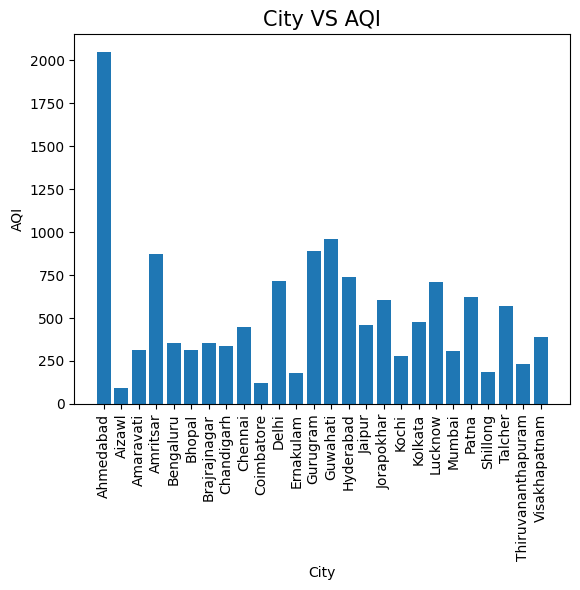

In [14]:
plt.bar(df['City'], df['AQI'])
plt.xlabel('City')
plt.ylabel('AQI')
plt.title('City VS AQI' ,fontsize =15)
plt.xticks(rotation =90)
plt.show()

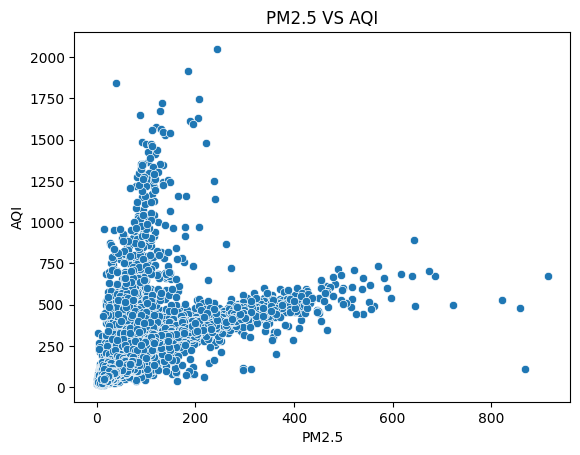

In [15]:
sns.scatterplot(data=df ,x='PM2.5', y='AQI')
plt.title('PM2.5 VS AQI')
plt.show()

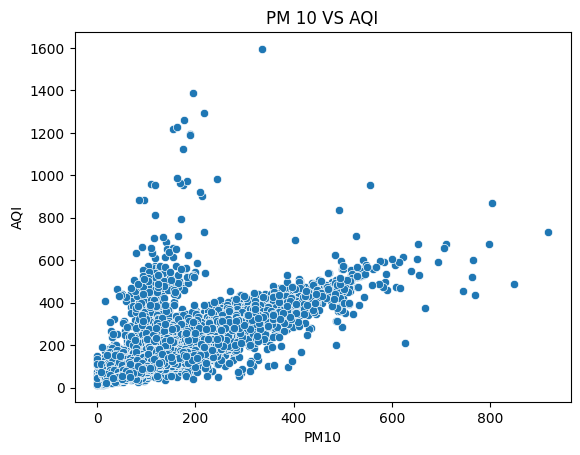

In [16]:
sns.scatterplot(data=df ,x='PM10', y='AQI')
plt.title('PM 10 VS AQI')
plt.show()

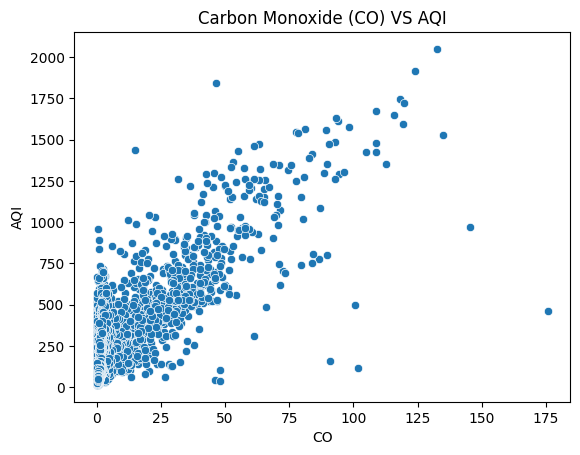

In [17]:
sns.scatterplot(data=df ,x='CO', y='AQI')
plt.title('Carbon Monoxide (CO) VS AQI')
plt.show()

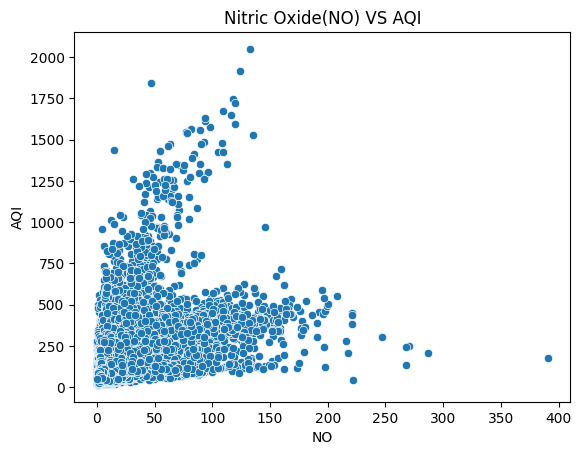

In [18]:
sns.scatterplot(data=df ,x='NO', y='AQI')
plt.title('Nitric Oxide(NO) VS AQI')
plt.show()

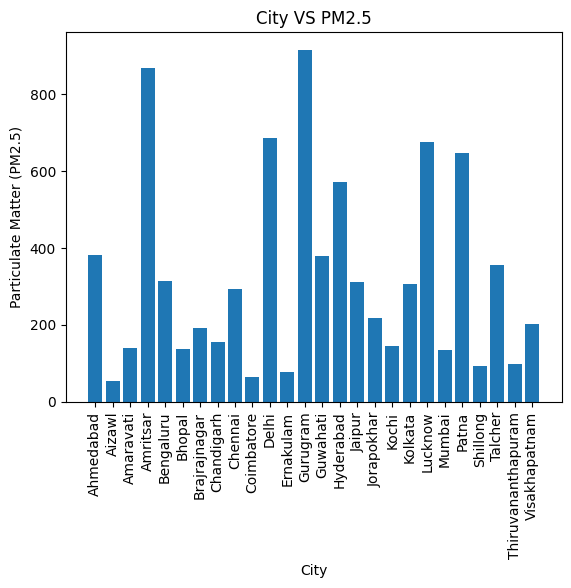

In [19]:
plt.bar(df['City'], df['PM2.5'])
plt.xlabel('City')
plt.ylabel('Particulate Matter (PM2.5)')
plt.title('City VS PM2.5')
plt.xticks(rotation =90)
plt.show()

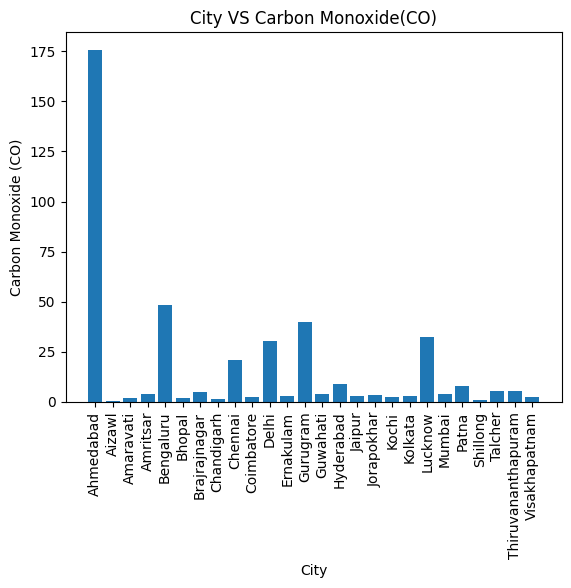

In [20]:
plt.bar(df['City'], df['CO'])
plt.xlabel('City')
plt.ylabel('Carbon Monoxide (CO)')
plt.title('City VS Carbon Monoxide(CO)')
plt.xticks(rotation =90)
plt.show()

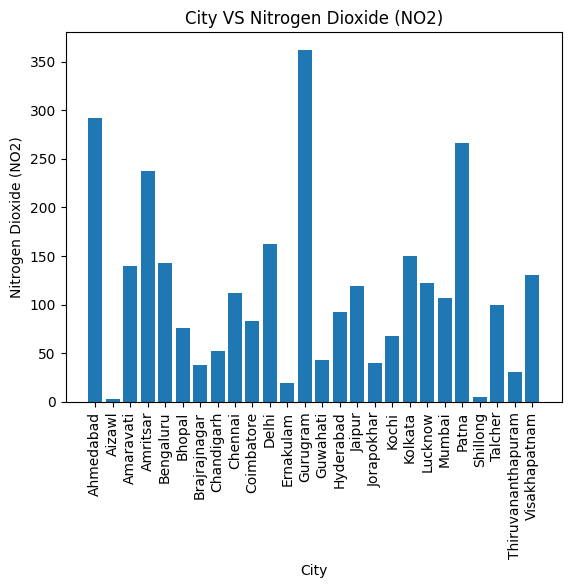

In [21]:
plt.bar(df['City'], df['NO2'])
plt.xlabel('City')
plt.ylabel('Nitrogen Dioxide (NO2)')
plt.title('City VS Nitrogen Dioxide (NO2)')
plt.xticks(rotation =90)
plt.show()

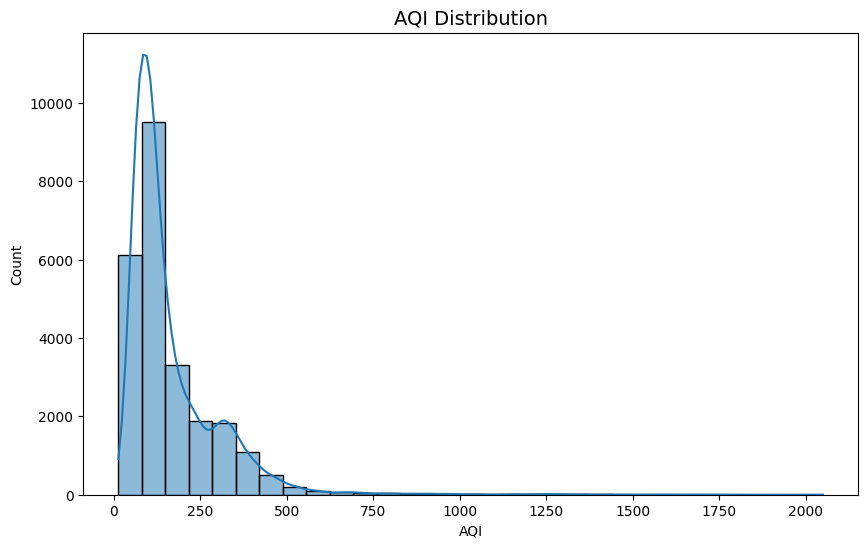

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='AQI', bins=30, kde=True)
plt.title('AQI Distribution', fontsize=14)
plt.show()

**Drop features :**

Note:- I used only "AQI" as target. Because i solve 'Regression' problem ,but "AQI_Bucket" is type of 'Classification' problem.

In [23]:
df.drop(['Date', 'AQI_Bucket'],axis=1,inplace=True)

In [24]:
df.shape

(24850, 14)

**Features Selection**

In [25]:
# Define "X" as Input value and "y" as target value
X = df.drop('AQI', axis=1)
y = df['AQI']

# train_test_split

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
X_train.shape,X_test.shape

((19880, 13), (4970, 13))

# Preprocessing the Dataset

This section prepares the dataset for machine learning by handling missing values, encoding categorical variables, and scaling numerical features using a preprocessing pipeline.

In [29]:
# 1. Encode the categorical column
# 2. Fill the missing value with imputer 
# 3. Scaling the numericals value
# 4. Create Pipeline for Imputer
# 5. Create ColumnTransformer 

In [30]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [31]:
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

In [32]:
num_pipeline =Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

In [33]:
# Column Transformer 

In [34]:
preprocess_data = ColumnTransformer([
    ('encode', OneHotEncoder(handle_unknown='ignore'),cat_cols),
    ('num_pipe', num_pipeline ,num_cols)
])

In [35]:
X_train_cleaned = preprocess_data.fit_transform(X_train)
X_test_cleaned = preprocess_data.transform(X_test)

# Apply Models (Baseline models)

**1. Linear Regression (Baseline)**

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
lr_model = LinearRegression()

In [38]:
lr_model.fit(X_train_cleaned,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
y_pred_lr = lr_model.predict(X_test_cleaned)

In [40]:
y_pred_lr

array([110.46161488, 193.65343567, 114.24469221, ..., 156.09400873,
       106.66990909, 115.14818187], shape=(4970,))

**Evaluate the model (Linear Regression)**

In [41]:
from sklearn.metrics import r2_score, mean_absolute_error ,root_mean_squared_error

In [42]:
lr_score = r2_score(y_test,y_pred_lr)

In [43]:
lr_score

0.8238258464297126

In [44]:
lr_mae =mean_absolute_error(y_test,y_pred_lr)

In [45]:
lr_mae

30.06048795944072

In [46]:
lr_rmse =root_mean_squared_error(y_test,y_pred_lr)

In [47]:
lr_rmse

56.797259213287184

**2. Random Forest Regression (Baseline)**

In [48]:
from sklearn.ensemble import RandomForestRegressor

In [49]:
rf_model = RandomForestRegressor(random_state=42)

In [50]:
rf_model.fit(X_train_cleaned,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [51]:
y_pred_rf = rf_model.predict(X_test_cleaned)

**Evaluate the model (Random Forest regressor)**

In [52]:
# r2score
rf_score = r2_score(y_test,y_pred_rf)

In [53]:
rf_score

0.9097422571437709

In [54]:
# MAE
rf_mae = mean_absolute_error(y_test,y_pred_rf)

In [55]:
rf_mae

20.4822588123982

In [56]:
# RMSE
rf_rmse = root_mean_squared_error(y_test,y_pred_rf)

In [57]:
rf_rmse

40.653553835217686

**Cross Validation for Random Forest**

In [58]:
from sklearn.model_selection import cross_val_score

In [59]:
cv_score = cross_val_score(
    estimator= rf_model,
    X= X_train_cleaned,
    y= y_train,
    cv= 5,
    scoring= 'r2',
    n_jobs= -1
) 

In [60]:
print(cv_score)

[0.87411204 0.91527319 0.90882379 0.907972   0.90971632]


In [61]:
print(round(np.mean(cv_score)*100,2))

90.32


**3. XGBoost Model (Baseline)**

In [62]:
from xgboost import XGBRegressor

In [63]:
xgb = XGBRegressor()

In [64]:
xgb.fit(X_train_cleaned,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [65]:
y_pred_xgb = xgb.predict(X_test_cleaned)

**Evaluate the model (XGBRegressor)**

In [66]:
# r2 score
xgb_score = r2_score(y_test,y_pred_xgb)

In [67]:
# MAE
xgb_mae = mean_absolute_error(y_test,y_pred_xgb)

In [68]:
# RMSE
xgb_rmse = root_mean_squared_error(y_test,y_pred_xgb)

**Cross Validation for XGBRegressor**

In [69]:
cv_score_xgb = cross_val_score(
    estimator= xgb,
    X= X_train_cleaned,
    y= y_train,
    cv= 5,
    scoring='r2',
    n_jobs= -1
)

In [70]:
print(cv_score_xgb)

[0.88559495 0.90874238 0.9073605  0.89952294 0.89709175]


In [71]:
print(round(np.mean(cv_score_xgb)*100,2))

89.97


# Model's Comparison

In [72]:
model_compare = pd.DataFrame({
    'Models' :[
        'Linear Regression',
        'Random Forest Regressor',
        'XGB Regressor'
    ],
    'R2 Score' : [
        lr_score,
        rf_score,
        xgb_score
    ],
    'MAE' :[
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE' : [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ]
})
model_compare = model_compare.sort_values(by='R2 Score', ascending=False)

In [73]:
model_compare

,Models,R2 Score,MAE,RMSE
1,Random Forest Regressor,0.909742,20.482259,40.653554
2,XGB Regressor,0.896584,21.366710,43.516200
0,Linear Regression,0.823826,30.060488,56.797259


**Random forest regressor** gives good performance as compare to other two model, Linear regression or XGB regressor

# Hyperparameter Tuning 
* **GridSearchCV**

In [74]:
from sklearn.model_selection import GridSearchCV

In [75]:
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [76]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

In [77]:
grid.fit(X_train_cleaned,y_train)

Fitting 3 folds for each of 288 candidates, totalling 864 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [78]:
print(grid.best_params_)  

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


These are best parameters for random forest model.

In [79]:
print("Best CV Score:")
print(round(grid.best_score_,4))

Best CV Score:
0.9041


In [80]:
# Apply best parameters on random forest model.
best_rf = grid.best_estimator_

In [81]:
y_pred_best_rf = best_rf.predict(X_test_cleaned)

In [82]:
y_pred_best_rf

array([102.69166667, 201.44      , 103.3255    , ..., 162.194     ,
        89.99733333,  91.633     ], shape=(4970,))

**Evaluate the best_rf model**

In [83]:
# R2 Score 
score = r2_score(y_test,y_pred_best_rf)
print('R2 Score :', score)

R2 Score : 0.9110820517040615


In [84]:
# MAE
best_rf_mae = mean_absolute_error(y_test,y_pred_best_rf)
print('MAE :',best_rf_mae)

MAE : 20.786258726605386


In [85]:
# RMSE
best_rf_rmse = root_mean_squared_error(y_test,y_pred_best_rf)
print('RMSE :',best_rf_rmse)

RMSE : 40.350693090544915


# Cheaking Overfitting of Random forest (Hyperparameter Tuning)

In [86]:
train_pred_rf = best_rf.predict(X_train_cleaned)
train_acc_rf = r2_score(y_train,train_pred_rf)

test_pred_rf = best_rf.predict(X_test_cleaned)
test_acc_rf = r2_score(y_test,test_pred_rf)

In [87]:
print('Training score :',train_acc_rf)
print('Testint score :', test_acc_rf)

Training score : 0.986875265073502
Testint score : 0.9110820517040615


# Final Model Pipeline

In [103]:
final_pipeline = Pipeline([
    ('preprocesser', preprocess_data),
    ('model',RandomForestRegressor(
        n_estimators=300,
        max_depth= None,
        max_features= "sqrt",
        min_samples_split= 2,
        min_samples_leaf= 1,
        random_state=42
    ))
])

Parameters are used from GridSearchCV.

In [104]:
final_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesser', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode', ...), ('num_pipe', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [105]:
# Predict final pipeline

In [106]:
final_pred = final_pipeline.predict(X_test)

In [107]:
final_pred

array([101.11944444, 201.73666667, 103.65583333, ..., 165.6       ,
        87.85333333,  91.73      ], shape=(4970,))

**Evaluate final pipeline model**

In [108]:
# R2 score
final_r2_score = r2_score(y_test,final_pred)
print("Final R2 Score :", final_r2_score)

Final R2 Score : 0.9112767426594257


In [109]:
# Final MAE
final_mae = mean_absolute_error(y_test,final_pred)
print("Final MAE :",final_mae)

Final MAE : 20.817505761849375


In [110]:
# Final RMSE
final_rmse = root_mean_squared_error(y_test,final_pred)
print("Final RMSE :", final_rmse)

Final RMSE : 40.3064938029062


# Save Model

In [111]:
import joblib

In [112]:
joblib.dump(final_pipeline, "aqi_prediction_pipeline.pkl", compress=3)

['aqi_prediction_pipeline.pkl']

# Deployment (Streamlit app)

In [113]:
import streamlit as st
import pandas as pd
import joblib

# Load Saved Pipeline
model = joblib.load("aqi_prediction_pipeline.pkl")

# Title
st.title("Air Quality Index Prediction")

st.write("Enter the pollutant values below to predict AQI.")

# Input Fields

city = st.selectbox(
    "Select City",
    ["Ahmedabad", "Bengaluru", "Chennai", "Delhi", "Hyderabad", "Kolkata", "Mumbai","Lucknow","Patna","Gurugram",
    "Visakhapatnam","Amritsar","Jaipur","Thiruvananthapuram","Chandigarh","Amaravati","Jorapokhar","Guwahati","Bhopal","Brajrajnagar",
    "Talcher","Coimbatore","Shillong","Kochi","Ernakulam","Aizawl"]
)

pm25 = st.number_input("PM2.5")
pm10 = st.number_input("PM10")
no = st.number_input("NO")
no2 = st.number_input("NO2")
nox = st.number_input("NOx")
nh3 = st.number_input("NH3")
co = st.number_input("CO")
so2 = st.number_input("SO2")
o3 = st.number_input("O3")
benzene = st.number_input("Benzene")
toluene = st.number_input("Toluene")
xylene = st.number_input("Xylene")

# Prediction

if st.button("Predict AQI"):

    input_data = pd.DataFrame({
        "City": [city],
        "PM2.5": [pm25],
        "PM10": [pm10],
        "NO": [no],
        "NO2": [no2],
        "NOx": [nox],
        "NH3": [nh3],
        "CO": [co],
        "SO2": [so2],
        "O3": [o3],
        "Benzene": [benzene],
        "Toluene": [toluene],
        "Xylene": [xylene]
    })

    prediction = model.predict(input_data)

    st.success(f"Predicted AQI : {prediction[0]:.2f}")

    # AQI Category

    if prediction[0] <= 50:
        st.success("AQI Category : Good")

    elif prediction[0] <= 100:
        st.success("AQI Category : Satisfactory")

    elif prediction[0] <= 200:
        st.warning("AQI Category : Moderate")

    elif prediction[0] <= 300:
        st.warning("AQI Category : Poor")

    elif prediction[0] <= 400:
        st.error("AQI Category : Very Poor")

    else:
        st.error("AQI Category : Severe")

2026-07-02 07:33:28.019 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:33:28.092 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:33:28.101 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:33:28.109 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:33:28.111 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:33:28.117 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:33:28.169 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 07:33:28.174 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar